In [ ]:
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pathlib import Path
import polars.selectors as cs

In [ ]:
input_folder=Path().resolve().parent /'input'
output_folder=Path().resolve().parent/'output'
output_folder.mkdir(parents=True, exist_ok=True)

In [ ]:
pl.enable_string_cache()
pl.Config.set_streaming_chunk_size(2000000)

Building customer demographics behaviour

## Importing the library defined in the working directory

In [ ]:
import importlib
import lib
importlib.reload(lib)
vis=lib.loadProfile(df_hp)

In [ ]:
%%time
data=pl.scan_parquet(input_folder/'load_profile_buildingID_*')
BUILDINGS=data.collect().select(pl.col('bldg_id')).unique()

## Initial Data Preprocessing

## The aim of this section is to find as many features as possible to build accurate hypothesis

In [62]:
%%time
Meta_data=pl.scan_parquet(input_folder/'Meta_Data.parquet').with_columns(pl.col('bldg_id').cast(pl.UInt32)).filter(
    pl.col('bldg_id').is_in(BUILDINGS.to_series().to_list())).select(pl.col('in.occupants','in.state','in.county',
                        'in.representative_income','in.area_median_income','in.income',
                        'in.income_recs_2020','in.income_recs_2015', 'in.building_america_climate_zone',
                        'in.bedrooms','in.tenure','in.household_has_tribal_persons','bldg_id')
                ).unique()
Meta_data.collect()

CPU times: user 116 ms, sys: 10.1 ms, total: 126 ms
Wall time: 78.6 ms


in.occupants,in.state,in.county,in.representative_income,in.area_median_income,in.income,in.income_recs_2020,in.income_recs_2015,in.building_america_climate_zone,in.bedrooms,in.tenure,in.household_has_tribal_persons,bldg_id
str,str,str,f32,str,str,str,str,str,str,str,str,u32
"""5""","""FL""","""G1200810""",63276.0,"""80-100%""","""60000-69999""","""60000-99999""","""60000-79999""","""Hot-Humid""","""5""","""Owner""","""No""",100016
"""2""","""FL""","""G1201270""",4951.0,"""0-30%""","""<10000""","""<20000""","""<20000""","""Hot-Humid""","""4""","""Owner""","""No""",100075
"""5""","""FL""","""G1200110""",65485.0,"""80-100%""","""60000-69999""","""60000-99999""","""60000-79999""","""Hot-Humid""","""3""","""Owner""","""No""",100024
"""3""","""FL""","""G1200310""",67973.0,"""100-120%""","""60000-69999""","""60000-99999""","""60000-79999""","""Hot-Humid""","""5""","""Owner""","""No""",10004
"""2""","""FL""","""G1200190""",37142.0,"""60-80%""","""35000-39999""","""20000-39999""","""20000-39999""","""Hot-Humid""","""3""","""Owner""","""No""",100313
…,…,…,…,…,…,…,…,…,…,…,…,…
"""2""","""FL""","""G1201010""",255215.0,"""150%+""","""200000+""","""150000+""","""140000+""","""Hot-Humid""","""4""","""Owner""","""No""",1001
"""0""","""FL""","""G1200390""",null,"""Not Available""","""Not Available""","""Not Available""","""Not Available""","""Hot-Humid""","""3""","""Not Available""","""Not Available""",100314
"""2""","""FL""","""G1200860""",75632.0,"""100-120%""","""70000-79999""","""60000-99999""","""60000-79999""","""Hot-Humid""","""2""","""Renter""","""No""",100316


## Merging the Meta Data into the main data

In [ ]:
data=data.join(Meta_data, on="bldg_id")

## Getting the columns of the data to use to build the data dictionary

In [ ]:
schema=data.collect_schema().names()

## Prepare the data dictionary based on the existing columns

In [ ]:
df_dictionary=pl.read_csv(input_folder/"data_dictionary.tsv", separator='\t').filter(pl.col('field_name').is_in(schema))
df_dictionary.write_csv(output_folder/'data_dictionary.csv')

## Data Reduction

In [ ]:
df_hp=data.with_columns(
            pl.col('timestamp').dt.weekday().alias('day of the week'),
            pl.col('timestamp').dt.hour().alias('hour of the day'),
            pl.col('timestamp').dt.day().alias('day of the month'),
            pl.col('timestamp').dt.ordinal_day().alias('day of the year'),
            pl.col('timestamp').dt.week().alias('week of the year'),
            pl.col('timestamp').dt.month().alias('month of the year'),
            pl.col('out.electricity.cooling.energy_consumption..kwh').alias('out.electricity.AC.energy_consumption..kwh'),
            pl.col('timestamp').dt.quarter().alias('quarter')).with_columns(
            pl.when(pl.col('day of the week').is_in([6,7])).then(1).otherwise(0).alias('IsWeekend')
            ).select(cs.matches('^out.electricity.*|^bldg*|^day*|^hour*|^week*|^month*|^time*|^quarter|^IsWeekend')).collect()

* Checking missing values

In [ ]:
df_hp.null_count()

No missing values within the data

In [ ]:
# TODO: Do some visualizations to detect outlier--might include from the one below
# TODO: Do data transformation then and see the resulted output and measure the difference between both
# TODO: Data integration is already included
# TODO: Data reduction might be considered by doing something like PCA

## End of data preprocessing

In [ ]:
# Run boxplots
vis.boxplot_exp()

In [ ]:
# Run histograms
vis.hist_exp()

In [ ]:
# Run Boxen plot for large distributions
vis.boxen_exp()

### Now we want to see the total amount spent if its holiday or not

In [ ]:
vis.barplot_seaborn('out.electricity.total.energy_consumption..kwh', 'IsWeekend')

In [ ]:
df_hp1.head(10)

## Visualization of the long duration appliances usage

Long duration appliances are water heaters, refrigerators, Gas Stove

## First Hypothesis

the energy consumption patterns is significantly determined by the temporal attributes

In [ ]:
## TODO: Some hypotheses should be made to visulize the relationship of between divices consumption with the time pattern

### Sub Hypothesis 1: the hour of the day singificantly impact the consumption pattern of long duration appliances

In [ ]:
long_duration_hr=df_hp.select('hour of the day', 
                            'out.electricity.heating.energy_consumption..kwh',
                           'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
                           'out.electricity.AC.energy_consumption..kwh',
                            'out.electricity.hot_water.energy_consumption..kwh',
                            'out.electricity.refrigerator.energy_consumption..kwh',
                            'out.electricity.television.energy_consumption..kwh',
                            'out.electricity.total.energy_consumption..kwh',
                           ).pipe(vis.edit_column_names).group_by('hour of the day').agg(pl.all().sum()).sort('hour of the day')

In [ ]:
vis.display_totals(long_duration_hr,'out.electricity.total', 'hour of the day')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_hr, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_hr,'hour of the day', 'out.electricity.AC')

In [ ]:
vis._barplot_seaborn(long_duration_hr, 'hour of the day', 'out.electricity.AC')

# Discussion
As seen in the previous plot AC usage increases towards the mid of the day and starts plummeting towards later nights

## we Found that the ac correlates more to the values to the total consumption of energy

In [ ]:
vis.long_dev_temporal_based(long_duration_hr, 'hour of the day')

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_hr, 'hour of the day')

# Dicussion
The p-value for the correlation between all appliances and total consumption with the hour of the day is all less then 0.05
Indicating a strong correlation, therefore we reject the null hypothesis and we accept the alternative
therefore, hour of the day significantly determines the consumption patterns

Refrigerator has shown the highest correlation with the hour of the day column

In [ ]:
vis.display_totals(long_duration_hr, 'hour of the day',"out.electricity.refrigerator")

In [ ]:
vis._barplot_seaborn(long_duration_hr,'hour of the day',"out.electricity.refrigerator")

The second strongly correlated appliance is television as people to have thier tvs on in the end of the night

In [ ]:
vis.display_totals(long_duration_hr, 'hour of the day',"out.electricity.television")

In [ ]:
vis._barplot_seaborn(long_duration_hr,'hour of the day',"out.electricity.television")

____________

### Sub hypothesis 2: the day of the month singificantly impact the consumption pattern

In [ ]:
long_duration_dm=df_hp.select('day of the month', 
                            'out.electricity.heating.energy_consumption..kwh',
                           'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
                           'out.electricity.AC.energy_consumption..kwh',
                            'out.electricity.hot_water.energy_consumption..kwh',
                            'out.electricity.refrigerator.energy_consumption..kwh',
                            'out.electricity.television.energy_consumption..kwh',
                            'out.electricity.total.energy_consumption..kwh',
                           ).pipe(vis.edit_column_names).group_by('day of the month').agg(pl.all().sum()).sort('day of the month')
long_duration_dm.select(pl.col('day of the month').max())

In [ ]:
vis.display_totals(long_duration_dm,'day of the month','out.electricity.total')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration_dm, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration_dm,'day of the month','out.electricity.AC')

## we Found that the ac correlates more to the values to the total consumption of energy

In [ ]:
vis.long_dev_temporal_based(long_duration_dm, 'day of the month')

In [59]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration_dm, 'day of the month')

,p_value,pearson correlation:,col
0,0.000006,-0.715009,out.electricity.heating
0,0.009991,-0.455678,out.electricity.cooling_fans_pumps
0,0.008276,-0.465759,out.electricity.AC
0,0.012116,-0.445048,out.electricity.hot_water
0,0.033669,-0.382558,out.electricity.refrigerator
0,0.018931,-0.419120,out.electricity.television
0,0.000240,-0.613898,out.electricity.total


In [ ]:
## TODO: Find the answer of the relationship between the day of the month and the heating appliance

## Discussion
there is a weird relationship between the heating and the day of the month which needs to be answered in this section

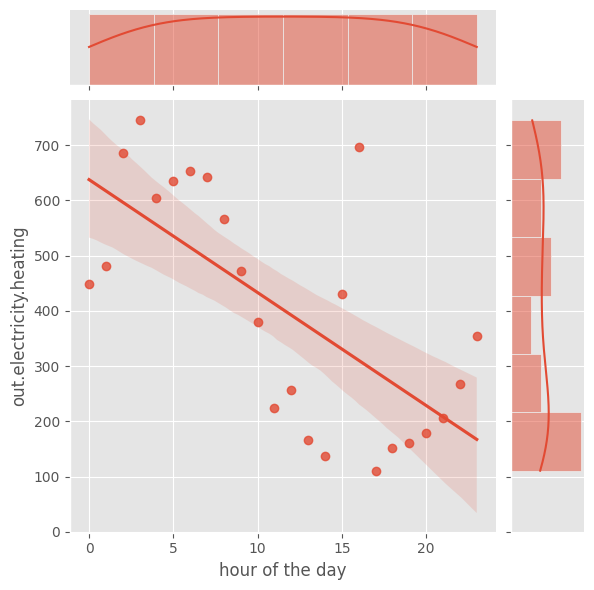

In [60]:
vis.display_totals(long_duration_hr, 'hour of the day',"out.electricity.heating")

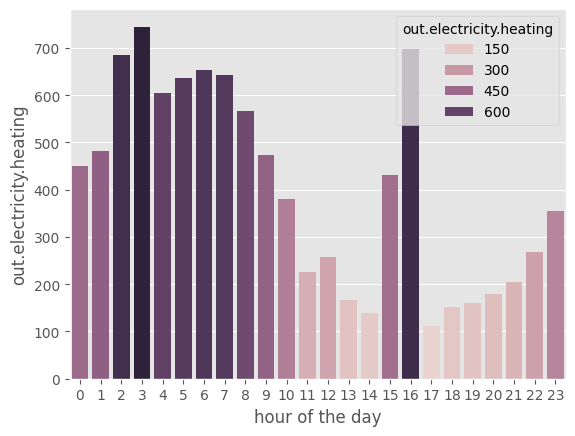

In [61]:
vis._barplot_seaborn(long_duration_hr,'hour of the day',"out.electricity.heating")

### Objective 3: the week of the year singificantly impact the consumption pattern

In [ ]:
long_duration=df_hp1.select('week of the year', 
                            'out.electricity.heating.energy_consumption..kwh',
                           'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
                           'out.electricity.AC.energy_consumption..kwh',
                            'out.electricity.hot_water.energy_consumption..kwh',
                            'out.electricity.refrigerator.energy_consumption..kwh',
                            'out.electricity.television.energy_consumption..kwh',
                            'out.electricity.total.energy_consumption..kwh',
                           ).pipe(vis.edit_column_names).group_by('week of the year').agg(pl.all().sum()).sort('week of the year')

In [ ]:
vis.display_totals(long_duration,'out.electricity.total', 'hour of the day')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration,'out.electricity.AC', 'hour of the day')

## we Found that the ac correlates more to the values to the total consumption of energy

In [ ]:
vis.long_dev_hourly(long_duration)

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration, 'hour of the day')

### Objective 4: the month of the year singificantly impact the consumption pattern

In [ ]:
long_duration=df_hp1.select('month of the year', 
                            'out.electricity.heating.energy_consumption..kwh',
                           'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
                           'out.electricity.AC.energy_consumption..kwh',
                            'out.electricity.hot_water.energy_consumption..kwh',
                            'out.electricity.refrigerator.energy_consumption..kwh',
                            'out.electricity.television.energy_consumption..kwh',
                            'out.electricity.total.energy_consumption..kwh',
                           ).pipe(vis.edit_column_names).group_by('month of the year').agg(pl.all().sum()).sort('month of the year')

In [ ]:
vis.display_totals(long_duration,'out.electricity.total', 'hour of the day')

In [ ]:
# apply pearson correlation test to see which appliance contrinbutes more to the total consumption of energy
vis.test_corr(long_duration, 'out.electricity.total')

In [ ]:
vis.display_totals(long_duration,'out.electricity.AC', 'hour of the day')

## we Found that the ac correlates more to the values to the total consumption of energy

In [ ]:
vis.long_dev_hourly(long_duration)

In [ ]:
## now lets test if there is a correlation between the hour of the day and the total consunmption and some appliances
vis.test_corr(long_duration, 'hour of the day')

## Second Hypothesis

net total energy consumption determines the peak load periods

## Third Hypothesis

Simultaneous operation of two appliance creates a load on user's side

In [ ]:
##TODO: Make a pairplot for all long duration appliances generally
## TODO: Make a pairplot for all long duration appliances using correlations like is_Holiday
sns.pairplot(data=long_duration.to_pandas())

This proves hypothesis four that there is a relationship between devices

## Fourth Hypothesis

User Behaviour analysis